# Titanic Dataset - PyTorch Neural Network Classification

This notebook implements deep learning approaches using PyTorch for Titanic survival classification with activation function comparisons.

## Objectives:
1. Load preprocessed data
2. Create PyTorch datasets and dataloaders
3. Build two neural network architectures:
   - **Basic feedforward network** (minimum 2 hidden layers)
   - **Advanced network** with Dropout, Batch Normalization, and L2 regularization
4. **Compare activation functions**: ReLU, LeakyReLU, GELU
5. Train models for 10-20 epochs with fixed hyperparameters
6. Evaluate model performance with appropriate metrics for class imbalance
7. Visualize training curves and loss/metric graphs
8. Save trained models

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score
)

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_STATE)
    torch.cuda.manual_seed_all(RANDOM_STATE)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 1. Load and Prepare Data

In [ ]:
data_path = Path('../data/processed/titanic_processed.csv')
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (891, 29)

Columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson', 'HasCabin', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeGroup_Teenager', 'AgeGroup_Young Adult', 'AgeGroup_Adult', 'AgeGroup_Senior', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown']

First few rows:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,FarePerPerson,...,AgeGroup_Adult,AgeGroup_Senior,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
0,0,3,0,22.0,1,0,7.2500,2,0,3.62500,...,0,0,0,0,0,0,0,0,0,1
1,1,1,1,38.0,1,0,71.2833,2,0,35.64165,...,1,0,0,1,0,0,0,0,0,0
2,1,3,1,26.0,0,0,7.9250,1,1,7.92500,...,0,0,0,0,0,0,0,0,0,1
3,1,1,1,35.0,1,0,53.1000,2,0,26.55000,...,0,0,0,1,0,0,0,0,0,0
4,0,3,0,35.0,0,0,8.0500,1,1,8.05000,...,0,0,0,0,0,0,0,0,0,1


In [3]:
# Separate features and target
X = df.drop('Survived', axis=1).values
y = df['Survived'].values

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"\nClass distribution:")
unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Class {label}: {count} ({count/len(y)*100:.2f}%)")

Features shape: (891, 28)
Target shape: (891,)
Number of features: 28

Class distribution:
Class 0: 549 (61.62%)
Class 1: 342 (38.38%)


In [ ]:

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)


X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set size: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

Training set size: 534 (59.9%)
Validation set size: 178 (20.0%)
Test set size: 179 (20.1%)


In [5]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")
print(f"\nScaled features statistics (training set):")
print(f"Mean: {X_train_scaled.mean(axis=0)[:5]}...")  # Show first 5
print(f"Std: {X_train_scaled.std(axis=0)[:5]}...")  # Show first 5

Feature scaling completed.

Scaled features statistics (training set):
Mean: [ 1.62375315e-16  7.11041712e-17  7.59639958e-17  1.14348813e-17
 -2.61962736e-17]...
Std: [1. 1. 1. 1. 1.]...


In [6]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val_scaled)
y_val_tensor = torch.FloatTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test)

print("Data converted to PyTorch tensors.")
print(f"Training tensor shape: {X_train_tensor.shape}")
print(f"Validation tensor shape: {X_val_tensor.shape}")
print(f"Test tensor shape: {X_test_tensor.shape}")

Data converted to PyTorch tensors.
Training tensor shape: torch.Size([534, 28])
Validation tensor shape: torch.Size([178, 28])
Test tensor shape: torch.Size([179, 28])


In [7]:
# Create datasets and dataloaders
batch_size = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Batch size: {batch_size}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Batch size: 32
Number of training batches: 17
Number of validation batches: 6
Number of test batches: 6


## 2. Define Neural Network Architectures

In [ ]:
def get_activation(activation_name):
    """Return activation function based on name."""
    if activation_name == 'relu':
        return nn.ReLU()
    elif activation_name == 'leaky_relu':
        return nn.LeakyReLU(negative_slope=0.01)
    elif activation_name == 'gelu':
        return nn.GELU()
    else:
        raise ValueError(f"Unknown activation: {activation_name}")


class BasicNN(nn.Module):
    """Basic feedforward neural network with 2 hidden layers."""
    
    def __init__(self, input_size, hidden_size1=64, hidden_size2=32, activation='relu'):
        super(BasicNN, self).__init__()
        self.activation_name = activation
        
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.activation1 = get_activation(activation)
        
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.activation2 = get_activation(activation)
        
        self.fc3 = nn.Linear(hidden_size2, 1)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.activation1(x)
        
        x = self.fc2(x)
        x = self.activation2(x)
        
        x = self.fc3(x)
        x = torch.sigmoid(x)
        return x


class AdvancedNN(nn.Module):
    """Advanced neural network with Dropout, Batch Normalization, and L2 regularization.
    Minimum 2 hidden layers with regularization techniques."""
    
    def __init__(self, input_size, hidden_size1=64, hidden_size2=32, 
                 dropout_rate=0.3, activation='relu'):
        super(AdvancedNN, self).__init__()
        self.activation_name = activation
        
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.bn1 = nn.BatchNorm1d(hidden_size1)
        self.activation1 = get_activation(activation)
        self.dropout1 = nn.Dropout(dropout_rate)
        
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.bn2 = nn.BatchNorm1d(hidden_size2)
        self.activation2 = get_activation(activation)
        self.dropout2 = nn.Dropout(dropout_rate)
        
        # Output layer
        self.fc3 = nn.Linear(hidden_size2, 1)
        
    def forward(self, x):
        # First layer
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.activation1(x)
        x = self.dropout1(x)
        
        # Second layer
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.activation2(x)
        x = self.dropout2(x)
        
        # Output
        x = self.fc3(x)
        x = torch.sigmoid(x)
        return x


print("Neural network architectures defined:")
print("1. BasicNN - Basic feedforward network (2 hidden layers)")
print("2. AdvancedNN - Advanced network with Dropout, BatchNorm, L2 regularization")
print("\nActivation functions supported: ReLU, LeakyReLU, GELU")

Neural network architectures defined:
1. BasicNN - Basic feedforward network (2 hidden layers)
2. AdvancedNN - Advanced network with Dropout, BatchNorm, L2 regularization

Activation functions supported: ReLU, LeakyReLU, GELU


## 3. Training Functions

In [9]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        labels = labels.unsqueeze(1)  # Add dimension for BCE loss
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * inputs.size(0)
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def validate(model, val_loader, criterion, device):
    """Validate the model."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []
    all_probabilities = []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            labels = labels.unsqueeze(1)
            
            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item() * inputs.size(0)
            predicted = (outputs > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(outputs.cpu().numpy())
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, all_predictions, all_labels, all_probabilities


def train_model(model, train_loader, val_loader, criterion, optimizer, 
                num_epochs, device, model_name="Model"):
    """Complete training loop for fixed number of epochs."""
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    print(f"\nTraining {model_name} for {num_epochs} epochs...")
    
    for epoch in range(num_epochs):
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        val_loss, val_acc, _, _, _ = validate(model, val_loader, criterion, device)
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Print progress
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] - "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    print(f"Training completed for {model_name}!")
    print(f"Final - Val Loss: {history['val_loss'][-1]:.4f}, Val Acc: {history['val_acc'][-1]:.4f}")
    
    return model, history

print("Training functions defined.")

Training functions defined.


## 4. Evaluation Functions

In [ ]:
def evaluate_model(model, test_loader, device):
    """Evaluate model on test set."""
    model.eval()
    all_predictions = []
    all_labels = []
    all_probabilities = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            predicted = (outputs > 0.5).float()
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probabilities.extend(outputs.cpu().numpy())
    
    all_predictions = np.array(all_predictions).flatten()
    all_labels = np.array(all_labels).flatten()
    all_probabilities = np.array(all_probabilities).flatten()
    
    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(all_labels, all_predictions)
    recall = recall_score(all_labels, all_predictions)
    f1 = f1_score(all_labels, all_predictions)
    roc_auc = roc_auc_score(all_labels, all_probabilities)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'predictions': all_predictions,
        'labels': all_labels,
        'probabilities': all_probabilities
    }


def plot_training_history(history, model_name):
    """Plot training and validation metrics."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss plot
    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'], label='Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'Training History - Loss ({model_name})')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy plot
    axes[1].plot(history['train_acc'], label='Train Accuracy')
    axes[1].plot(history['val_acc'], label='Validation Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'Training History - Accuracy ({model_name})')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(labels, predictions, model_name):
    """Plot confusion matrix."""
    cm = confusion_matrix(labels, predictions)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Did not survive', 'Survived'],
                yticklabels=['Did not survive', 'Survived'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()


def plot_roc_curve(labels, probabilities, model_name):
    """Plot ROC curve."""
    fpr, tpr, _ = roc_curve(labels, probabilities)
    roc_auc = roc_auc_score(labels, probabilities)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("Evaluation functions defined.")

Evaluation functions defined.


## 5. Activation Function Comparison Experiments

We will train both Basic and Advanced networks with different activation functions:
- **ReLU** (Rectified Linear Unit)
- **LeakyReLU** (Leaky ReLU with negative slope = 0.01)
- **GELU** (Gaussian Error Linear Unit)

Each model will be trained for 15 epochs with fixed hyperparameters:
- Optimizer: Adam
- Learning Rate: 0.001
- L2 Regularization (weight_decay): 1e-5 for Advanced models

### 5.1 Basic Neural Network - Activation Function Comparison

In [11]:
print("="*80)
print("BASIC NEURAL NETWORK - ACTIVATION FUNCTION COMPARISON")
print("="*80)

# Fixed hyperparameters
input_size = X_train.shape[1]
NUM_EPOCHS = 15
LEARNING_RATE = 0.001
HIDDEN_SIZE1 = 64
HIDDEN_SIZE2 = 32

# Store results
basic_models = {}
basic_histories = {}
basic_results = {}

# Activation functions to compare
activations = ['relu', 'leaky_relu', 'gelu']

for activation in activations:
    print(f"\n{'='*80}")
    print(f"Training Basic NN with {activation.upper()} activation")
    print(f"{'='*80}")
    
    # Initialize model
    model = BasicNN(
        input_size=input_size,
        hidden_size1=HIDDEN_SIZE1,
        hidden_size2=HIDDEN_SIZE2,
        activation=activation
    ).to(device)
    
    # Print model info
    print(f"\nModel Architecture:")
    print(model)
    print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")
    print(f"Activation function: {activation}")
    
    # Define loss and optimizer (no L2 regularization for basic model)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    # Train
    model, history = train_model(
        model, train_loader, val_loader, criterion, optimizer,
        num_epochs=NUM_EPOCHS, device=device, 
        model_name=f"Basic NN ({activation.upper()})"
    )
    
    # Store model and history
    basic_models[activation] = model
    basic_histories[activation] = history
    
    # Evaluate on test set
    results = evaluate_model(model, test_loader, device)
    basic_results[activation] = results
    
    print(f"\nTest Set Results for Basic NN ({activation.upper()}):")
    print(f"Accuracy: {results['accuracy']:.4f}")
    print(f"Precision: {results['precision']:.4f}")
    print(f"Recall: {results['recall']:.4f}")
    print(f"F1 Score: {results['f1']:.4f}")
    print(f"ROC AUC: {results['roc_auc']:.4f}")

print(f"\n{'='*80}")
print("BASIC NN TRAINING COMPLETED FOR ALL ACTIVATIONS")
print(f"{'='*80}")

BASIC NEURAL NETWORK - ACTIVATION FUNCTION COMPARISON

Training Basic NN with RELU activation

Model Architecture:
BasicNN(
  (fc1): Linear(in_features=28, out_features=64, bias=True)
  (activation1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (activation2): ReLU()
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)

Total parameters: 3969
Activation function: relu

Training Basic NN (RELU) for 15 epochs...
Epoch [1/15] - Train Loss: 0.6638, Train Acc: 0.6779 - Val Loss: 0.6394, Val Acc: 0.6798
Epoch [5/15] - Train Loss: 0.4263, Train Acc: 0.8090 - Val Loss: 0.4598, Val Acc: 0.7921
Epoch [10/15] - Train Loss: 0.3707, Train Acc: 0.8521 - Val Loss: 0.4385, Val Acc: 0.8202
Epoch [15/15] - Train Loss: 0.3454, Train Acc: 0.8764 - Val Loss: 0.4401, Val Acc: 0.8315
Training completed for Basic NN (RELU)!
Final - Val Loss: 0.4401, Val Acc: 0.8315

Test Set Results for Basic NN (RELU):
Accuracy: 0.7933
Precision: 0.7581
Recall: 0.6812
F1 Score: 0.7176
ROC AUC:

Basic NN - Training Curves Comparison


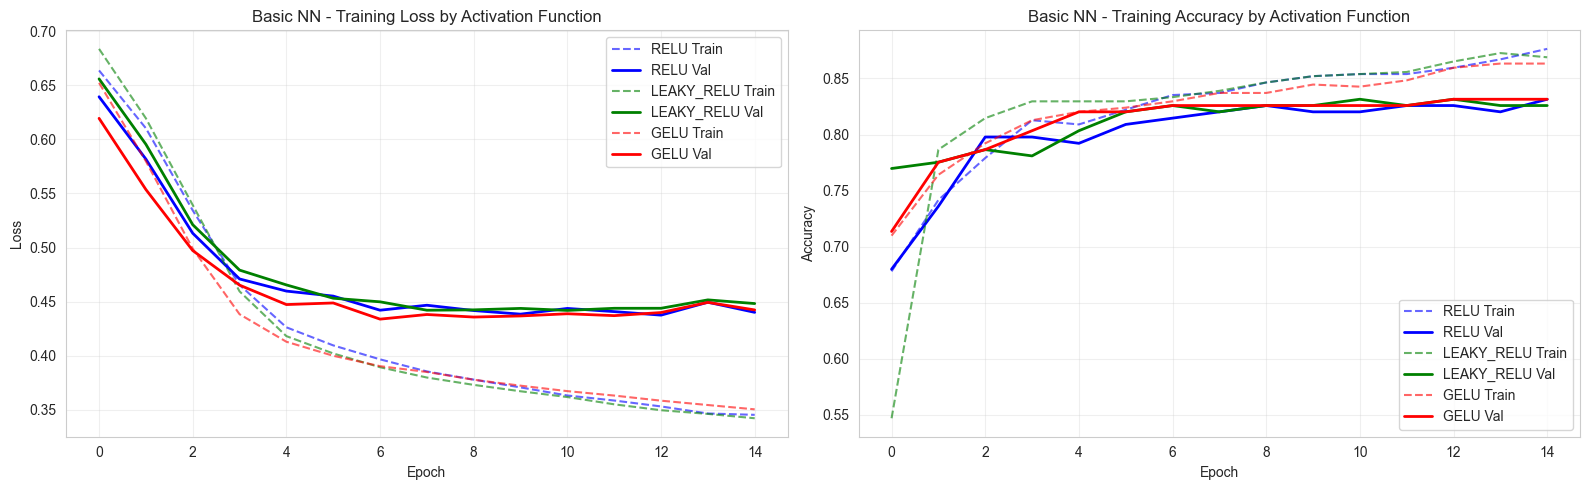

In [12]:
# Visualize Basic NN training histories
print("Basic NN - Training Curves Comparison")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = {'relu': 'blue', 'leaky_relu': 'green', 'gelu': 'red'}

# Loss plot
for activation in activations:
    history = basic_histories[activation]
    axes[0].plot(history['train_loss'], '--', color=colors[activation], alpha=0.6, 
                 label=f'{activation.upper()} Train')
    axes[0].plot(history['val_loss'], '-', color=colors[activation], linewidth=2,
                 label=f'{activation.upper()} Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Basic NN - Training Loss by Activation Function')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
for activation in activations:
    history = basic_histories[activation]
    axes[1].plot(history['train_acc'], '--', color=colors[activation], alpha=0.6,
                 label=f'{activation.upper()} Train')
    axes[1].plot(history['val_acc'], '-', color=colors[activation], linewidth=2,
                 label=f'{activation.upper()} Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Basic NN - Training Accuracy by Activation Function')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

BASIC NN - METRICS COMPARISON BY ACTIVATION FUNCTION
            Accuracy  Precision  Recall  F1 Score  ROC AUC
Activation                                                
RELU          0.7933     0.7581  0.6812    0.7176   0.8273
LEAKY_RELU    0.7821     0.7419  0.6667    0.7023   0.8200
GELU          0.7933     0.7581  0.6812    0.7176   0.8307


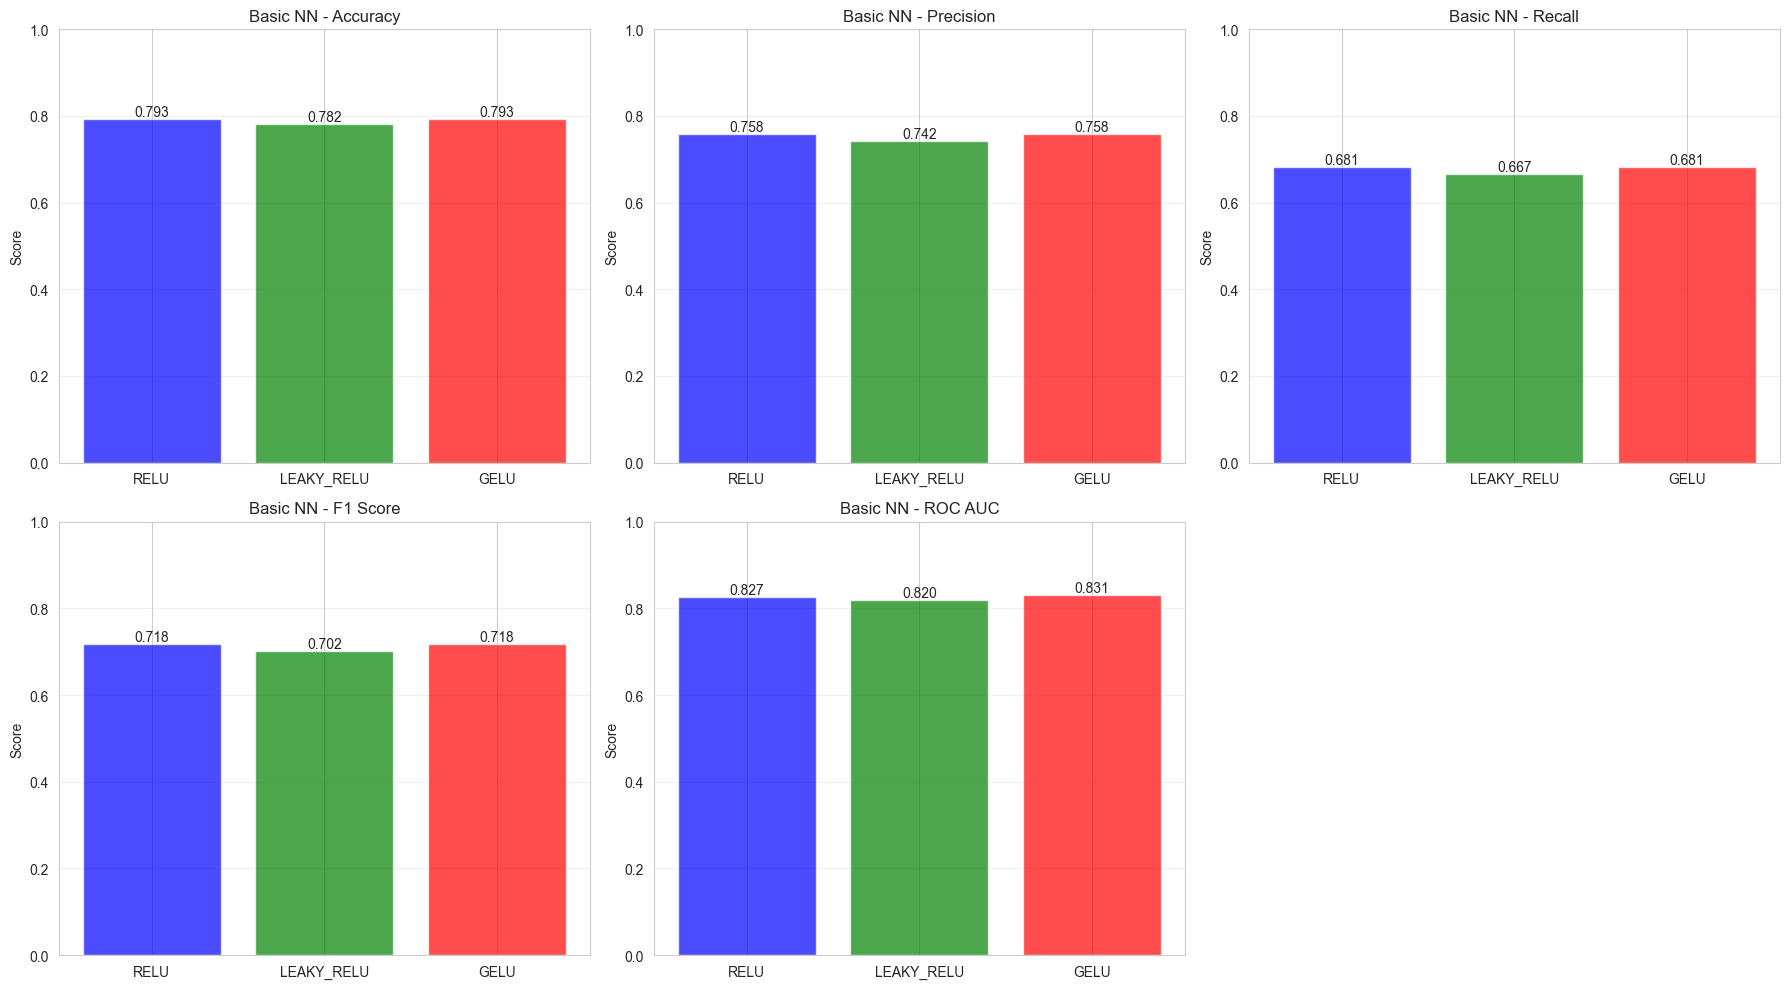

In [13]:
# Compare Basic NN metrics across activation functions
basic_comparison = pd.DataFrame([
    {
        'Activation': activation.upper(),
        'Accuracy': basic_results[activation]['accuracy'],
        'Precision': basic_results[activation]['precision'],
        'Recall': basic_results[activation]['recall'],
        'F1 Score': basic_results[activation]['f1'],
        'ROC AUC': basic_results[activation]['roc_auc']
    }
    for activation in activations
]).set_index('Activation')

print("="*80)
print("BASIC NN - METRICS COMPARISON BY ACTIVATION FUNCTION")
print("="*80)
print(basic_comparison.round(4))

# Visualize metrics comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
colors_list = ['blue', 'green', 'red']

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    bars = ax.bar(range(len(activations)), basic_comparison[metric].values, 
                   color=colors_list, alpha=0.7)
    ax.set_xticks(range(len(activations)))
    ax.set_xticklabels([a.upper() for a in activations])
    ax.set_ylabel('Score')
    ax.set_title(f'Basic NN - {metric}')
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

### 5.2 Advanced Neural Network - Activation Function Comparison

Advanced network with Dropout (0.3), Batch Normalization, and L2 regularization (weight_decay=1e-5)

In [14]:
print("="*80)
print("ADVANCED NEURAL NETWORK - ACTIVATION FUNCTION COMPARISON")
print("="*80)

# Fixed hyperparameters
DROPOUT_RATE = 0.3
WEIGHT_DECAY = 1e-5  # L2 regularization

# Store results
advanced_models = {}
advanced_histories = {}
advanced_results = {}

for activation in activations:
    print(f"\n{'='*80}")
    print(f"Training Advanced NN with {activation.upper()} activation")
    print(f"{'='*80}")
    
    # Initialize model
    model = AdvancedNN(
        input_size=input_size,
        hidden_size1=HIDDEN_SIZE1,
        hidden_size2=HIDDEN_SIZE2,
        dropout_rate=DROPOUT_RATE,
        activation=activation
    ).to(device)
    
    # Print model info
    print(f"\nModel Architecture:")
    print(model)
    print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")
    print(f"Activation function: {activation}")
    print(f"Dropout rate: {DROPOUT_RATE}")
    print(f"L2 regularization (weight_decay): {WEIGHT_DECAY}")
    
    # Define loss and optimizer with L2 regularization
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    
    # Train
    model, history = train_model(
        model, train_loader, val_loader, criterion, optimizer,
        num_epochs=NUM_EPOCHS, device=device, 
        model_name=f"Advanced NN ({activation.upper()})"
    )
    
    # Store model and history
    advanced_models[activation] = model
    advanced_histories[activation] = history
    
    # Evaluate on test set
    results = evaluate_model(model, test_loader, device)
    advanced_results[activation] = results
    
    print(f"\nTest Set Results for Advanced NN ({activation.upper()}):")
    print(f"Accuracy: {results['accuracy']:.4f}")
    print(f"Precision: {results['precision']:.4f}")
    print(f"Recall: {results['recall']:.4f}")
    print(f"F1 Score: {results['f1']:.4f}")
    print(f"ROC AUC: {results['roc_auc']:.4f}")

print(f"\n{'='*80}")
print("ADVANCED NN TRAINING COMPLETED FOR ALL ACTIVATIONS")
print(f"{'='*80}")

ADVANCED NEURAL NETWORK - ACTIVATION FUNCTION COMPARISON

Training Advanced NN with RELU activation

Model Architecture:
AdvancedNN(
  (fc1): Linear(in_features=28, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (activation1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (activation2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)

Total parameters: 4161
Activation function: relu
Dropout rate: 0.3
L2 regularization (weight_decay): 1e-05

Training Advanced NN (RELU) for 15 epochs...
Epoch [1/15] - Train Loss: 0.6746, Train Acc: 0.6030 - Val Loss: 0.6317, Val Acc: 0.7360
Epoch [5/15] - Train Loss: 0.4770, Train Acc: 0.8127 - Val Loss: 0.4781, Val Acc: 0.7978
Epoch [10/15] - Train Loss: 0.4274, Trai

Advanced NN - Training Curves Comparison


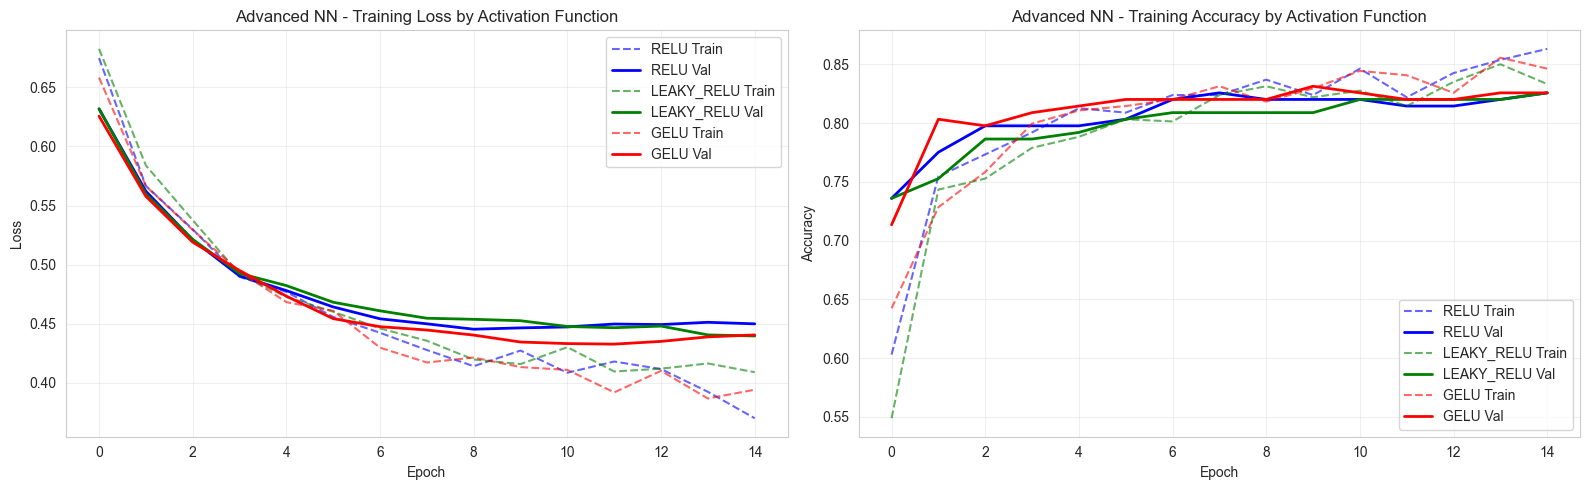

In [15]:
# Visualize Advanced NN training histories
print("Advanced NN - Training Curves Comparison")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss plot
for activation in activations:
    history = advanced_histories[activation]
    axes[0].plot(history['train_loss'], '--', color=colors[activation], alpha=0.6, 
                 label=f'{activation.upper()} Train')
    axes[0].plot(history['val_loss'], '-', color=colors[activation], linewidth=2,
                 label=f'{activation.upper()} Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Advanced NN - Training Loss by Activation Function')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
for activation in activations:
    history = advanced_histories[activation]
    axes[1].plot(history['train_acc'], '--', color=colors[activation], alpha=0.6,
                 label=f'{activation.upper()} Train')
    axes[1].plot(history['val_acc'], '-', color=colors[activation], linewidth=2,
                 label=f'{activation.upper()} Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Advanced NN - Training Accuracy by Activation Function')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ADVANCED NN - METRICS COMPARISON BY ACTIVATION FUNCTION
            Accuracy  Precision  Recall  F1 Score  ROC AUC
Activation                                                
RELU          0.7877     0.7385  0.6957    0.7164   0.8142
LEAKY_RELU    0.8101     0.7692  0.7246    0.7463   0.8242
GELU          0.7877     0.7385  0.6957    0.7164   0.8296


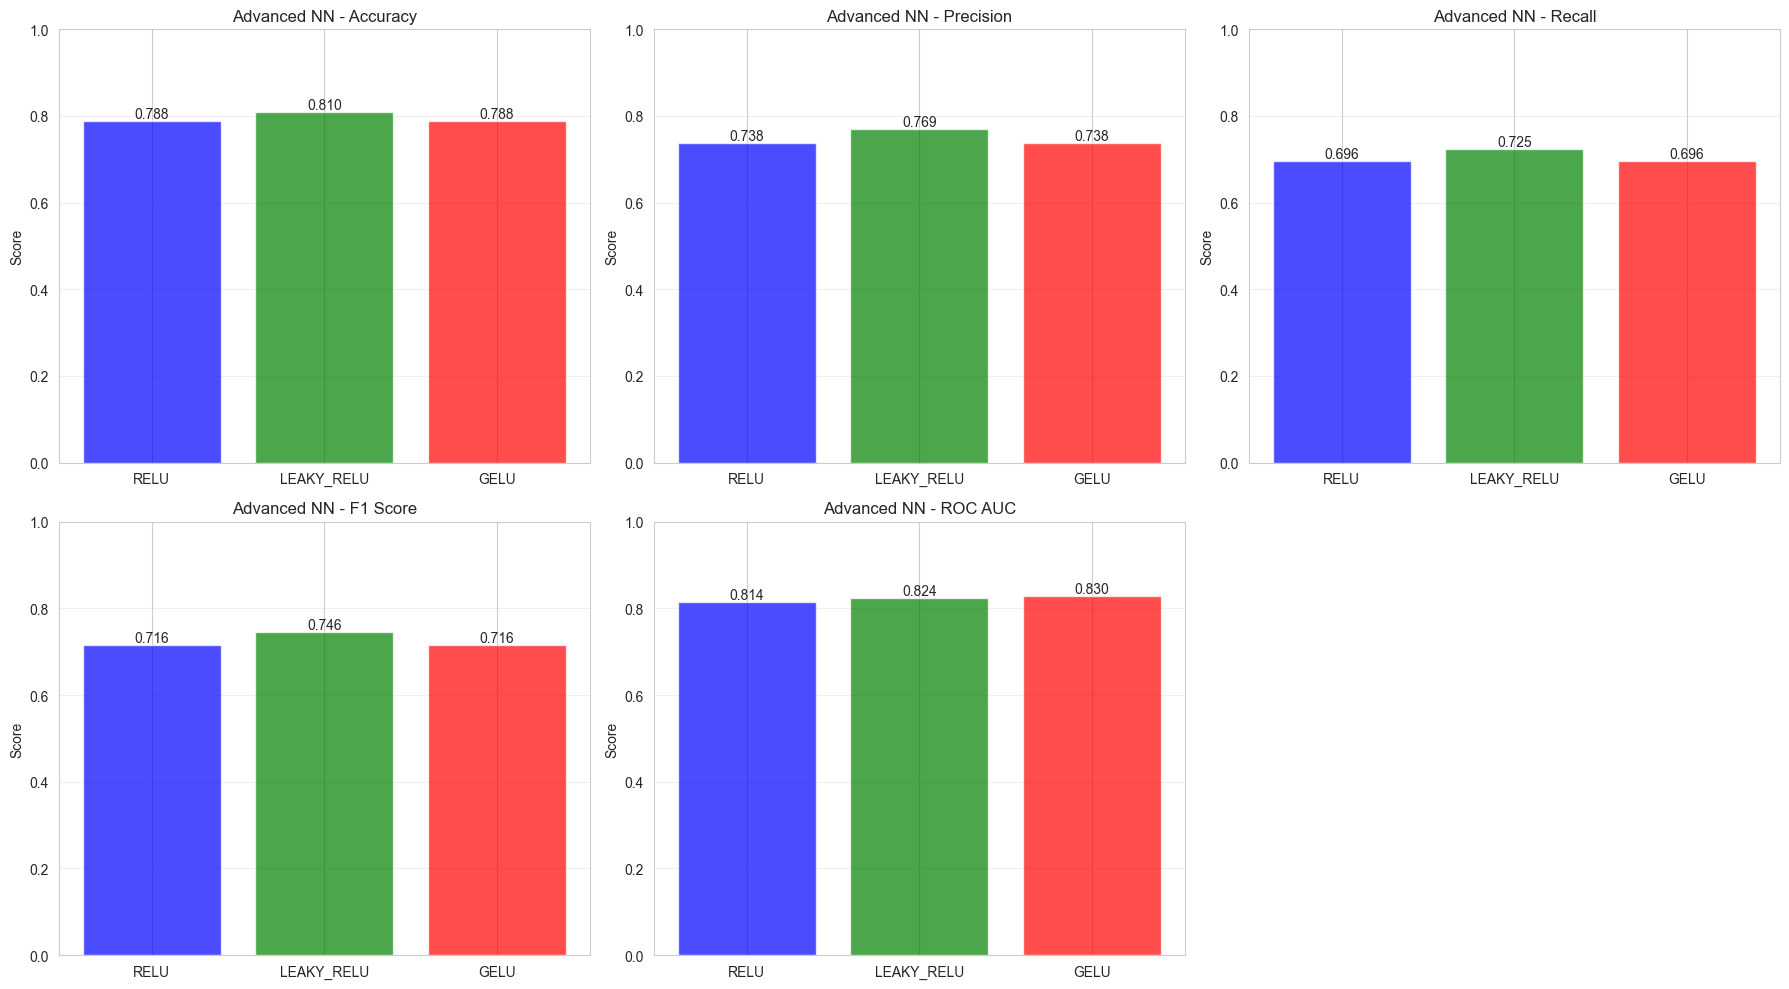

In [16]:
# Compare Advanced NN metrics across activation functions
advanced_comparison = pd.DataFrame([
    {
        'Activation': activation.upper(),
        'Accuracy': advanced_results[activation]['accuracy'],
        'Precision': advanced_results[activation]['precision'],
        'Recall': advanced_results[activation]['recall'],
        'F1 Score': advanced_results[activation]['f1'],
        'ROC AUC': advanced_results[activation]['roc_auc']
    }
    for activation in activations
]).set_index('Activation')

print("="*80)
print("ADVANCED NN - METRICS COMPARISON BY ACTIVATION FUNCTION")
print("="*80)
print(advanced_comparison.round(4))

# Visualize metrics comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    bars = ax.bar(range(len(activations)), advanced_comparison[metric].values, 
                   color=colors_list, alpha=0.7)
    ax.set_xticks(range(len(activations)))
    ax.set_xticklabels([a.upper() for a in activations])
    ax.set_ylabel('Score')
    ax.set_title(f'Advanced NN - {metric}')
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

In [17]:
## 6. Overall Comparison: Basic vs Advanced Networks

In [18]:
# Create comprehensive comparison table
all_results = []

for activation in activations:
    all_results.append({
        'Architecture': 'Basic NN',
        'Activation': activation.upper(),
        'Accuracy': basic_results[activation]['accuracy'],
        'Precision': basic_results[activation]['precision'],
        'Recall': basic_results[activation]['recall'],
        'F1 Score': basic_results[activation]['f1'],
        'ROC AUC': basic_results[activation]['roc_auc']
    })
    all_results.append({
        'Architecture': 'Advanced NN',
        'Activation': activation.upper(),
        'Accuracy': advanced_results[activation]['accuracy'],
        'Precision': advanced_results[activation]['precision'],
        'Recall': advanced_results[activation]['recall'],
        'F1 Score': advanced_results[activation]['f1'],
        'ROC AUC': advanced_results[activation]['roc_auc']
    })

comparison_df = pd.DataFrame(all_results)

print("="*80)
print("COMPLETE COMPARISON: ALL MODELS AND ACTIVATIONS")
print("="*80)
print(comparison_df.round(4).to_string(index=False))

# Find best models
print("\n" + "="*80)
print("BEST MODELS BY METRIC")
print("="*80)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']:
    best_idx = comparison_df[metric].idxmax()
    best_row = comparison_df.loc[best_idx]
    print(f"{metric:12s}: {best_row['Architecture']:12s} with {best_row['Activation']:10s} = {best_row[metric]:.4f}")

COMPLETE COMPARISON: ALL MODELS AND ACTIVATIONS
Architecture Activation  Accuracy  Precision  Recall  F1 Score  ROC AUC
    Basic NN       RELU    0.7933     0.7581  0.6812    0.7176   0.8273
 Advanced NN       RELU    0.7877     0.7385  0.6957    0.7164   0.8142
    Basic NN LEAKY_RELU    0.7821     0.7419  0.6667    0.7023   0.8200
 Advanced NN LEAKY_RELU    0.8101     0.7692  0.7246    0.7463   0.8242
    Basic NN       GELU    0.7933     0.7581  0.6812    0.7176   0.8307
 Advanced NN       GELU    0.7877     0.7385  0.6957    0.7164   0.8296

BEST MODELS BY METRIC
Accuracy    : Advanced NN  with LEAKY_RELU = 0.8101
Precision   : Advanced NN  with LEAKY_RELU = 0.7692
Recall      : Advanced NN  with LEAKY_RELU = 0.7246
F1 Score    : Advanced NN  with LEAKY_RELU = 0.7463
ROC AUC     : Basic NN     with GELU       = 0.8307


## 6. Overall Comparison: Basic vs Advanced Networks

In [19]:
# Create comprehensive comparison table
all_results = []

for activation in activations:
    all_results.append({
        'Architecture': 'Basic NN',
        'Activation': activation.upper(),
        'Accuracy': basic_results[activation]['accuracy'],
        'Precision': basic_results[activation]['precision'],
        'Recall': basic_results[activation]['recall'],
        'F1 Score': basic_results[activation]['f1'],
        'ROC AUC': basic_results[activation]['roc_auc']
    })
    all_results.append({
        'Architecture': 'Advanced NN',
        'Activation': activation.upper(),
        'Accuracy': advanced_results[activation]['accuracy'],
        'Precision': advanced_results[activation]['precision'],
        'Recall': advanced_results[activation]['recall'],
        'F1 Score': advanced_results[activation]['f1'],
        'ROC AUC': advanced_results[activation]['roc_auc']
    })

comparison_df = pd.DataFrame(all_results)

print("="*80)
print("COMPLETE COMPARISON: ALL MODELS AND ACTIVATIONS")
print("="*80)
print(comparison_df.round(4).to_string(index=False))

# Find best models
print("\n" + "="*80)
print("BEST MODELS BY METRIC")
print("="*80)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']:
    best_idx = comparison_df[metric].idxmax()
    best_row = comparison_df.loc[best_idx]
    print(f"{metric:12s}: {best_row['Architecture']:12s} with {best_row['Activation']:10s} = {best_row[metric]:.4f}")

COMPLETE COMPARISON: ALL MODELS AND ACTIVATIONS
Architecture Activation  Accuracy  Precision  Recall  F1 Score  ROC AUC
    Basic NN       RELU    0.7933     0.7581  0.6812    0.7176   0.8273
 Advanced NN       RELU    0.7877     0.7385  0.6957    0.7164   0.8142
    Basic NN LEAKY_RELU    0.7821     0.7419  0.6667    0.7023   0.8200
 Advanced NN LEAKY_RELU    0.8101     0.7692  0.7246    0.7463   0.8242
    Basic NN       GELU    0.7933     0.7581  0.6812    0.7176   0.8307
 Advanced NN       GELU    0.7877     0.7385  0.6957    0.7164   0.8296

BEST MODELS BY METRIC
Accuracy    : Advanced NN  with LEAKY_RELU = 0.8101
Precision   : Advanced NN  with LEAKY_RELU = 0.7692
Recall      : Advanced NN  with LEAKY_RELU = 0.7246
F1 Score    : Advanced NN  with LEAKY_RELU = 0.7463
ROC AUC     : Basic NN     with GELU       = 0.8307


## 8. Save Models

In [20]:
# Create models directory
models_dir = Path('../models/pytorch')
models_dir.mkdir(parents=True, exist_ok=True)

# Save all models
print("="*80)
print("SAVING MODELS")
print("="*80)

saved_models = []

for activation in activations:
    # Save Basic NN
    basic_path = models_dir / f'basic_nn_{activation}.pth'
    torch.save({
        'model_state_dict': basic_models[activation].state_dict(),
        'model_architecture': 'BasicNN',
        'activation': activation,
        'input_size': input_size,
        'hidden_size1': HIDDEN_SIZE1,
        'hidden_size2': HIDDEN_SIZE2,
        'num_epochs': NUM_EPOCHS,
        'learning_rate': LEARNING_RATE,
        'history': basic_histories[activation],
        'test_results': basic_results[activation]
    }, basic_path)
    saved_models.append(str(basic_path))
    print(f"✓ Saved: {basic_path.name}")
    
    # Save Advanced NN
    advanced_path = models_dir / f'advanced_nn_{activation}.pth'
    torch.save({
        'model_state_dict': advanced_models[activation].state_dict(),
        'model_architecture': 'AdvancedNN',
        'activation': activation,
        'input_size': input_size,
        'hidden_size1': HIDDEN_SIZE1,
        'hidden_size2': HIDDEN_SIZE2,
        'dropout_rate': DROPOUT_RATE,
        'weight_decay': WEIGHT_DECAY,
        'num_epochs': NUM_EPOCHS,
        'learning_rate': LEARNING_RATE,
        'history': advanced_histories[activation],
        'test_results': advanced_results[activation]
    }, advanced_path)
    saved_models.append(str(advanced_path))
    print(f"✓ Saved: {advanced_path.name}")

# Save scaler
scaler_path = models_dir / 'scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
saved_models.append(str(scaler_path))
print(f"✓ Saved: {scaler_path.name}")

# Save comparison results
comparison_path = models_dir / 'activation_comparison_results.csv'
comparison_df.to_csv(comparison_path, index=False)
saved_models.append(str(comparison_path))
print(f"✓ Saved: {comparison_path.name}")

print(f"\nTotal files saved: {len(saved_models)}")
print(f"Location: {models_dir.absolute()}")

SAVING MODELS
✓ Saved: basic_nn_relu.pth
✓ Saved: advanced_nn_relu.pth
✓ Saved: basic_nn_leaky_relu.pth
✓ Saved: advanced_nn_leaky_relu.pth
✓ Saved: basic_nn_gelu.pth
✓ Saved: advanced_nn_gelu.pth
✓ Saved: scaler.pkl
✓ Saved: activation_comparison_results.csv

Total files saved: 8
Location: c:\Users\alexp\Documents\Programach\Python\titanic-classification-labs\notebooks\..\models\pytorch
